In [ ]:
# Label Definitions
labels_map = {
    0: "T-Shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

In [ ]:
# Downloading and pre-processing the Fashion MNIST dataset
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

# In the transform, image is converted to PyTorch tensor. Convert pixel values from 0-255 to 0-1.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

# Loading the data in batches
from torch.utils.data import DataLoader
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.2MB/s]


In [ ]:
# Selecting GPU
import os
from torch import nn
from torchvision import transforms

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
# Defining neural network
# class NeuralNetwork(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         self.linear_relu_stack = nn.Sequential(
#             nn.Linear(28*28, 1024),
#             nn.ReLU(),
#             nn.Linear(1024, 512),
#             nn.ReLU(),
#             nn.Linear(512, 10),
#         )

#     def forward(self, x):
#         x = self.flatten(x)
#         logits = self.linear_relu_stack(x)
#         return logits

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Classification Head
            nn.Flatten(),

            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

# Move model to device
# model = NeuralNetwork().to(device)
model= CNN().to(device)
print(model)

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=3136, out_features=256, bias=True)
    (12): ReLU()
    (13): Linear(in_features=256, out_features=128, bias=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
          X, y = X.to(device), y.to(device)
          pred = model(X)
          test_loss += loss_fn(pred, y).item()
          correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
learning_rate = 1e-3
batch_size = 64

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299074  [   64/60000]
loss: 0.734313  [ 6464/60000]
loss: 0.613428  [12864/60000]
loss: 0.364536  [19264/60000]
loss: 0.307979  [25664/60000]
loss: 0.403307  [32064/60000]
loss: 0.387640  [38464/60000]
loss: 0.253243  [44864/60000]
loss: 0.342428  [51264/60000]
loss: 0.288044  [57664/60000]
Test Error: 
 Accuracy: 84.5%, Avg loss: 0.395521 

Epoch 2
-------------------------------
loss: 0.201579  [   64/60000]
loss: 0.314843  [ 6464/60000]
loss: 0.204435  [12864/60000]
loss: 0.382997  [19264/60000]
loss: 0.288647  [25664/60000]
loss: 0.207652  [32064/60000]
loss: 0.196734  [38464/60000]
loss: 0.229419  [44864/60000]
loss: 0.304679  [51264/60000]
loss: 0.557372  [57664/60000]
Test Error: 
 Accuracy: 89.6%, Avg loss: 0.282896 

Epoch 3
-------------------------------
loss: 0.113572  [   64/60000]
loss: 0.338638  [ 6464/60000]
loss: 0.154489  [12864/60000]
loss: 0.209411  [19264/60000]
loss: 0.354077  [25664/60000]
loss: 0.156234  [32064/600

In [ ]:
import torchvision.models as models

torch.save(model.state_dict(), "fashion_mnist.pth")
# model = NeuralNetwork()
model = CNN()

model.load_state_dict(torch.load("fashion_mnist.pth"))
model.eval()

CNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=3136, out_features=256, bias=True)
    (12): ReLU()
    (13): Linear(in_features=256, out_features=128, bias=True)
    (14): ReLU()
    (15): Linear(in_features=128, out_features=10, bias=True)
  )
)

# Model Evaluation
We use classification report, confusion matrix and per-class accuracy to evaluate the model that we have generated.

In [ ]:
all_predictions = []
all_labels = []

model.to(device)
model.eval()

with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        outputs = model(X)
        preds = outputs.argmax(dim=1)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

In [ ]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(classification_report(all_labels,all_predictions,target_names=list(labels_map.values())))

              precision    recall  f1-score   support

 T-Shirt/top       0.90      0.84      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.89      0.89      0.89      1000
       Dress       0.94      0.92      0.93      1000
        Coat       0.88      0.89      0.89      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.76      0.83      0.79      1000
     Sneaker       0.98      0.96      0.97      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.97      0.98      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

In [ ]:
# PER-CLASS ACCURACY
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for idx, acc in enumerate(class_accuracy):
    print(f"{labels_map[idx]:12s}: {acc*100:.2f}%")

T-Shirt/top : 84.30%
Trouser     : 98.80%
Pullover    : 88.90%
Dress       : 91.60%
Coat        : 89.10%
Sandal      : 99.10%
Shirt       : 82.60%
Sneaker     : 96.50%
Bag         : 98.50%
Ankle Boot  : 97.70%


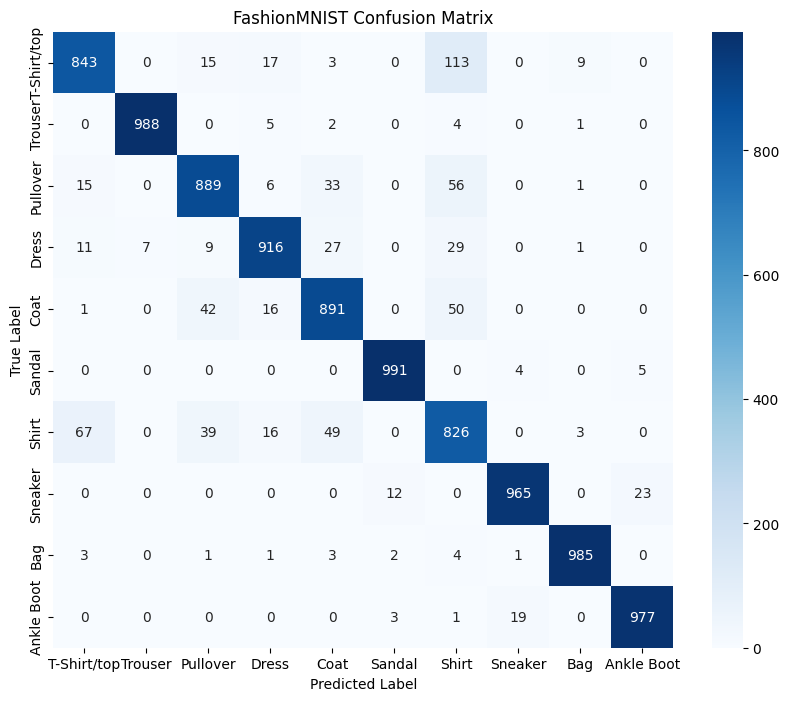

In [ ]:
# VISUALISING THE CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True,fmt="d",cmap="Blues",xticklabels=list(labels_map.values()),yticklabels=list(labels_map.values()))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

**OBSERVATIONS**:

1. Evidently, the model struggles most with upper-body garments (shirt, t-shirt, coat, pullover).
2. Shirt is the weakest as diagonal value is lowest among all classes. Notably, 113 t-shirts were actually predicted to be shirts while 67 shirts were predicted to be t-shirts.
3. Trouser and bag are almost perfectly recognised because no other class is similar to them.
4. Footwear classes are highly separable. Sandals are correctly identified with 99.1% accuracy, sneakers with 96.5% accuracy and ankle boots with 97.7% accuracy.

# EUROSAT PIPELINE

In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import (DataLoader,random_split,Subset)
from sklearn.metrics import (confusion_matrix,classification_report)

In [2]:
device = (torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [3]:
from google.colab import files
uploaded = files.upload()

with zipfile.ZipFile("train.zip", "r") as z:
    z.extractall("EuroSAT")
print("Extraction Complete")

Saving train.zip to train.zip
Extraction Complete


In [4]:
train_transform = v2.Compose([
    v2.Resize((64, 64)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomRotation(20),
    v2.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

val_transform = v2.Compose([
    v2.Resize((64, 64)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [11]:
train_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=train_transform) #Augmented
val_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=val_transform) #Not Augmented

In [12]:
dataset_size = len(train_dataset_full)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size,generator=generator) #Mix up the indices so that we don't leave out any particular
# label during training

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_dataset_full,train_indices)
val_dataset = Subset(val_dataset_full,val_indices)

In [13]:
batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True,num_workers=2)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=2)

In [14]:
print("Classes:")
print(train_dataset_full.classes)

print("\nClass Mapping:")
print(train_dataset_full.class_to_idx)

print(f"\nTraining Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Class Mapping:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Training Images: 18400
Validation Images: 4600


In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

In [16]:
class EuroSATCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128),
            nn.MaxPool2d(2)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256),
            ResidualBlock(256, 256),
            nn.MaxPool2d(2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # reducing parameter to avoid overfitting
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return self.classifier(x)

In [17]:
model = EuroSATCNN().to(device)
print(model)

EuroSATCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2

In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)

In [19]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    running_loss = 0
    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()

    return running_loss / len(dataloader)

In [20]:
def validation_loop(dataloader, model, loss_fn):

    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (
                pred.argmax(1) == y
            ).sum().item()
    val_loss /= len(dataloader)
    accuracy = correct / len(dataloader.dataset)
    return val_loss, accuracy

In [21]:
best_acc = 0
epochs = 20
for epoch in range(epochs):

    train_loss = train_loop(train_dataloader, model,loss_fn,optimizer)
    val_loss, val_acc = validation_loop(val_dataloader,model,loss_fn)
    scheduler.step(val_acc)
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100*val_acc:.2f}%"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(),"best_eurosat_model.pth")
        print("Best model saved.")

Epoch 1/20 | Train Loss: 1.1048 | Val Loss: 0.9239 | Val Acc: 69.93%
Best model saved.
Epoch 2/20 | Train Loss: 0.6459 | Val Loss: 1.0142 | Val Acc: 68.89%
Epoch 3/20 | Train Loss: 0.5273 | Val Loss: 0.5937 | Val Acc: 80.15%
Best model saved.
Epoch 4/20 | Train Loss: 0.4451 | Val Loss: 0.6575 | Val Acc: 77.70%
Epoch 5/20 | Train Loss: 0.3850 | Val Loss: 0.3937 | Val Acc: 86.26%
Best model saved.
Epoch 6/20 | Train Loss: 0.3302 | Val Loss: 0.2594 | Val Acc: 91.39%
Best model saved.
Epoch 7/20 | Train Loss: 0.3060 | Val Loss: 0.6095 | Val Acc: 83.48%
Epoch 8/20 | Train Loss: 0.2669 | Val Loss: 0.2423 | Val Acc: 92.09%
Best model saved.
Epoch 9/20 | Train Loss: 0.2504 | Val Loss: 0.2657 | Val Acc: 91.52%
Epoch 10/20 | Train Loss: 0.2304 | Val Loss: 0.1866 | Val Acc: 94.15%
Best model saved.
Epoch 11/20 | Train Loss: 0.2246 | Val Loss: 0.2099 | Val Acc: 93.50%
Epoch 12/20 | Train Loss: 0.1949 | Val Loss: 0.2929 | Val Acc: 91.02%
Epoch 13/20 | Train Loss: 0.1971 | Val Loss: 0.3731 | Val Acc

In [22]:
model.load_state_dict(
    torch.load(
        "best_eurosat_model.pth",
        weights_only=True
    )
)
model.eval()

EuroSATCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2

In [23]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X, y in val_dataloader:
        X = X.to(device)
        outputs = model(X)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.98      0.97       493
              Forest       0.99      0.98      0.99       510
HerbaceousVegetation       0.93      0.97      0.95       505
             Highway       0.96      0.99      0.98       391
          Industrial       0.97      0.98      0.98       438
             Pasture       0.97      0.95      0.96       320
       PermanentCrop       0.97      0.91      0.94       419
         Residential       0.99      0.98      0.98       550
               River       0.98      0.97      0.98       436
             SeaLake       0.99      0.99      0.99       538

            accuracy                           0.97      4600
           macro avg       0.97      0.97      0.97      4600
        weighted avg       0.97      0.97      0.97      4600



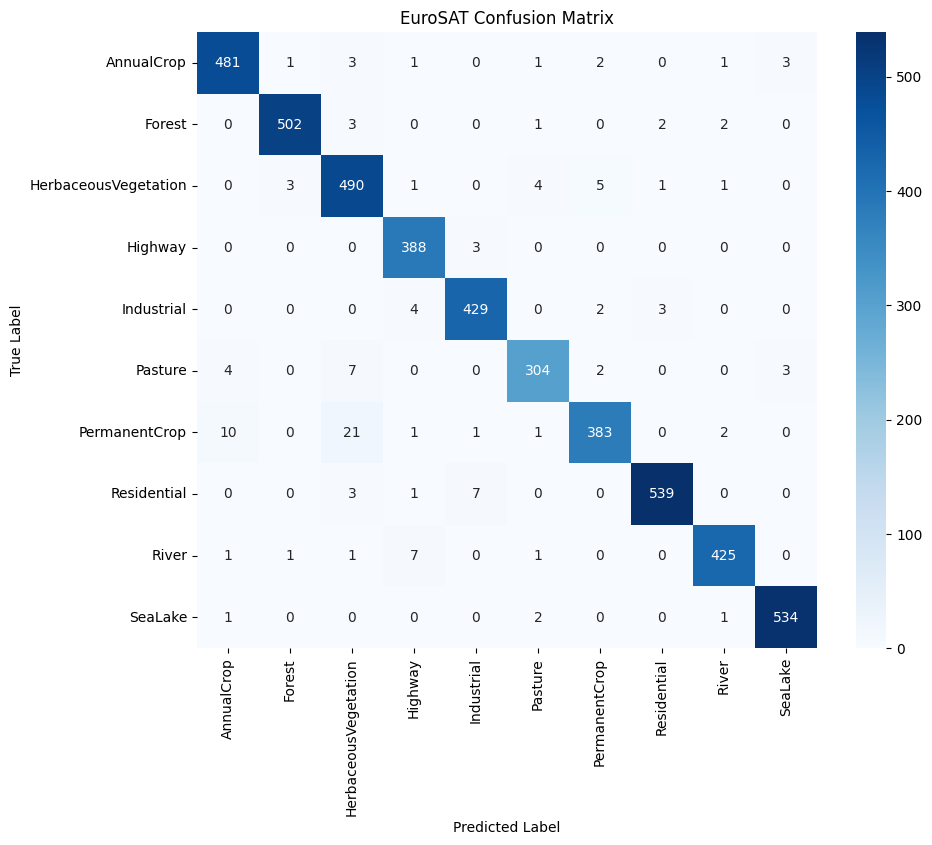

In [24]:
class_names = train_dataset_full.classes

print(classification_report(all_labels,all_preds,target_names=class_names))
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("EuroSAT Confusion Matrix")

plt.show()

In [25]:
from google.colab import files

print("Upload test.zip")
uploaded = files.upload()

with zipfile.ZipFile("test.zip", "r") as z:
    z.extractall("test_data")

Upload test.zip


Saving test.zip to test.zip


In [26]:
from torch.utils.data import Dataset
from PIL import Image
import os

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted(
            os.listdir(root_dir)
        )
    def __len__(self):
        return len(self.image_names)
    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(
            self.root_dir,
            image_name
        )
        image = Image.open(
            image_path
        ).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, image_name

In [29]:
test_dataset = TestDataset(root_dir="test_data/test_set",transform=val_transform)
test_dataloader = DataLoader(test_dataset,batch_size=64,shuffle=False)

In [30]:
model.eval()

image_ids = []
predicted_labels = []

with torch.no_grad():
    for images, names in test_dataloader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        image_ids.extend(names)
        predicted_labels.extend(
            preds.cpu().numpy()
        )

In [31]:
import pandas as pd

submission = pd.DataFrame({"img_id": image_ids,"label": predicted_labels})
submission.to_csv("submission.csv",index=False)
print(submission.head())

          img_id  label
0  img_00000.jpg      9
1  img_00001.jpg      3
2  img_00002.jpg      3
3  img_00003.jpg      2
4  img_00004.jpg      5


In [32]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>